# <span style="color:rgb(46,139,87)">Optimization for Data and Decision Sciences</span>

# <span style="color:rgb(46,139,87)">Master 2 MIAGE & MIAGE ID Apprentissage, 2025-2026</span>


# <span style="color:rgb(46,139,87)">Course Project - Around robust regression</span>



**The project assignment is described [here](https://www.lamsade.dauphine.fr/~croyer/ensdocs/ODS/ProjODS.pdf). The deadline is February 12, 2026 AOE.**

This Jupyter notebook can be obtained [here](https://www.lamsade.dauphine.fr/~croyer/ensdocs/ODS/SourcesProjODS.zip).

The lecture notes are available [here](https://www.lamsade.dauphine.fr/~croyer/ensdocs/ODS/PolyODS.pdf).

This notebook relies on NumPy and Scipy *(on Google Colab by default, you should install those on your local Python distribution).* Here is a link to a nice [Numpy tutorial](https://sebastianraschka.com/pdf/books/dlb/appendix_f_numpy-intro.pdf).

Any question, comment about this notebook can be sent to **clement.royer@lamsade.dauphine.fr**.

*Note: All parts of the notebook are meant to be independent. However, the next block should be executed prior to going further.*

In [ ]:
# Import useful librairies, functions, etc
###########################################

# Use matplotlib to plot results
%matplotlib inline
import matplotlib.pyplot as plt


# NumPy for vector and matrix calculus
import numpy as np

# Probability distributions
from numpy.random import binomial, multivariate_normal,normal, randn, uniform

# Linear algebra (efficient) routines in the SciPy library
from scipy.linalg import norm # For l1/l2 norms

# <span style="color:rgb(46,139,87)">1 Robust nonconvex regression and gradient descent</span>

## <span style="color:rgb(46,139,87)">1.1 Introduction and optimization formulation</span>

The goal of this part of the project is to study the behavior of gradient descent on a specific robust regression task expressed as a nonconvex optimization problem.

Given a data set under the form of a matrix $\mathbf{X} = [\mathbf{x}_i]_{i=1}^n \in \mathbb{R}^{n \times d}$ and a vector $\mathbf{y} = [y_i]_{i=1}^n \in \mathbb{R}^n$, we seek a solution to the following regression problem
$$
    \mbox{minimize}_{\mathbf{w} \in \mathbb{R}^d} f(\mathbf{w}):= \frac{1}{2 n} \sum_{i=1}^n\phi(\mathbf{x}_i^T \mathbf{w} - y_i),
$$
where $\phi: [0,\infty) \rightarrow [0,\infty)$ is the biweight loss function given by $\phi(t) = \frac{t^2}{1+t^2}$.

The function $f$ is twice continuously differentiable; moreover, for every $\mathbf{w} \in \mathbb{R}^d$, we have
$$
    \nabla f(\mathbf{w}) = \frac{1}{n} \sum_{i=1}^n \frac{\mathbf{x}_i^T \mathbf{w} -y_i}
    {(1+(\mathbf{x}_i^T \mathbf{w} - y_i)^2)^2}\,\mathbf{x}_i = \frac{1}{n} \mathbf{X}^T \mathbf{z} \in \mathbb{R}^d,
    \qquad
    \mathbf{z}= \left[ \frac{\mathbf{x}_i^T \mathbf{w} -y_i}
    {(1+(\mathbf{x}_i^T \mathbf{w} - y_i)^2)^2} \right] \in \mathbb{R}^n
$$
as well as
$$
    \nabla^2 f(\mathbf{w}) = \frac{1}{n} \mathbf{X}^T \mathrm{diag}\left(
    \left\{\frac{1-3(\mathbf{x}_i^T \mathbf{w} - y_i)^2}{(1+(\mathbf{x}_i^T \mathbf{w} - y_i)^2)^3}
    \right\}_{i=1}^n \right) \mathbf{X} \in \mathbb{R}^{d \times d}.
$$
where $\mathrm{diag}(\mathbf{v})$ is the diagonal matrix whose diagonal entries are the coefficients of $\mathbf{v}$.

*Note: For every $x \in \mathbb{R}^d$, we have $\|\nabla^2 f(\mathbf{x})\| \le \frac{1}{n}\left\|\mathbf{X}^T\right\|\|\mathbf{X}\|$, therefore the function has a Lipschitz continuous gradient.*

In [ ]:
## Biweight loss problem

### Biweight loss problem objective function
def biweightloss(X,y,w):
    '''
        Computation of a Tukey biweight loss function for a
        linear regression problem.

        Given a dataset (x_i,y_i) of m elements, this function
        computes for any w in R^d the value
            f(w)=(1/(2n))*sum(phi(x_i^T w - y_i)),
        where phi(t)=t^2/(1+t^2) is a smooth biweight loss.

        Inputs:
            X: n by d matrix
            y: n-dimensonal data vector
            w: argument of the loss function (d-dimensional)

        Output:
            Empirical loss value at w
    '''
    n = y.size
    r = X.dot(w)-y
    s = np.square(r)
    phi = 1-np.divide(1,1+s)
    return (1/(2*n))*np.sum(phi)

### Gradient of the biweight problem objective function
def biweightgrad(X,y,w):
    '''
        Gradient of a Tukey biweight loss function for a
        linear regression problem.

        Given a dataset (x_i,y_i) of m elements, this function
        computes for any w in R^d the value
            g(w)=(1/n)*sum((x_i^T w-y_i)/(1+(x_i^T w - y)^2))^2 * x_i)

        Inputs:
            X: n by d matrix
            y: n-dimensonal data vector
            w: argument of the loss function (d-dimensional)

        Output:
            Gradient of the empirical loss value at w
    '''
    n = y.size
    r = X.dot(w)-y
    s = np.square(1+np.square(r))
    g = X.T.dot(np.divide(r,s))
    return (1/n)*g

### Hessian matrix of the biweight problem objective function
def biweighthess(X,y,w):
    '''
        Hessian of a Tukey biweight loss function for a
        linear regression problem.

        Given a dataset (x_i,y_i) of m elements, this function
        computes for any w in R^d the value
            H(w)=(1/n)*X^T*D*X,
        where D is a diagonal matrix with i-th diagonal coefficient
        equal to
            (1-3(x_i^T w -y_i)^2)/(1+(x_i^T w - y)^2))^3

        Inputs:
            X: n by d matrix
            y: n-dimensional data vector
            w: argument of the loss function (d-dimensional)

        Output:
            Hessian matrix of the empirical loss value at w
    '''
    n = y.size
    s = np.square(X.dot(w)-y)
    v = np.divide(1-3*s,np.power(1+s,3))
    M = X.T@(np.diag(v))@X
    return (1/n)*M

## <span style="color:rgb(46,139,87)">1.2 Gradient descent</span>

This section provides an implementation of gradient descent for the problem at hand. We consider two variants on this method, based respectively on using a constant and an adaptive stepsize.

In [ ]:
## Gradient descent method
def gd_algo(X,y,w0,maxits=1000,eps=1e-4,linesearch='none',info=False):
    '''
        Gradient descent method for the robust regression problem.

        Inputs:
            X: n by d matrix of feature vectors
            y: vector of dimension n (labels)
            w0: initial point, d-dimensional vector
            maxits: Maximum number of iterations of the method
            eps: Tolerance for the gradient norm
            linesearch: Parameter indicating whether a line-search technique will be used
                'none': Only the Lipschitz constant will be used (default)
                'armijo': Armijo line search
            info: Boolean parameter, whether to display information about the iterations or not

        Outputs:
            w_output: Last iterate computed (NumPy array of length d)
            nits: Number of iterations
            nfevals: Number of function evaluations that were used
            objvals: History of function values (NumPy array of length nits)
            ngrads: History of gradient norms (NumPy array of length nits)
            flag: Convergence flag
                0: The algorithm converged
                1: The maximum number of iterations was reached
                -1: An error occurred

    '''

    ############
    # Initialization: Compute and plot some initial quantities

    # Problem dimensions
    n,d = X.shape

    # Initial value of current iterate
    w = w0.copy()


    # History of objective function values
    objvals = []

    # History of gradient norms
    ngrads = []

    # Initialize iteration counter
    nits=0

    # Initialize number of function evaluations
    nfevals = 0

    # Set convergence flag
    flag = -1

    if linesearch=='none':
        L = np.amax(np.diag(X.dot(X.T)))
        #L = (1/n) * norm(X, ord=2) ** 2
        alpha = 1/L
    else:
        L=1
        alpha = 1

    # Current objective
    obj = biweightloss(X,y,w)
    objvals.append(obj)
    nfevals += 1

    # Current gradient norm
    grad = biweightgrad(X,y,w)
    ng = norm(grad)
    ngrads.append(ng)

    # Plot the initial values
    if info:
        print("\nGradient Descent, Problem=",pb,", Line search=",linesearch)
        if linesearch=='none':
            print("Fixed step size:",1/L)
        print(' | '.join([name.center(8) for name in ["iter", "obj", "grad", "step size"]]))
        print(' | '.join([("%d" % nits).rjust(8),("%.2e" % obj).rjust(8),("%.2e" % ng).rjust(8),("%.2e" % alpha).rjust(8)]))

    if (ng<eps):
        flag = 0

    ####################
    # Main loop
    while (flag==-1):
        if linesearch=='none':
            w[:] = w - (1/L) * grad
        elif linesearch=='armijo':
            alpha,nf,fval,flagls = armijo(X,y,w,obj,grad,-grad,alpha,info)
            if flagls==1:
                flag = 1
                print("\tStep size from Armijo line search too small, number of step size tries:", nf)
                return w.copy(), w1vals, w2vals, nits, nfevals, np.array(objvals), np.array(ngrads), flag
            nfevals += nf
            w[:]=w-alpha*grad
            # Set initial value for the next line search
            alpha = 2*alpha

        # Compute and plot the new objective value and gradient norm
        if linesearch=='armijo':
            obj = fval
        else:
            obj = biweightloss(X,y,w)
            nfevals += 1

        objvals.append(obj)

        grad = biweightgrad(X,y,w)
        ng = norm(grad)
        ngrads.append(ng)

        # Increment the iteration count
        nits += 1

        # Print relevant information
        if info:
            print(' | '.join([("%d" % nits).rjust(8),("%.2e" % obj).rjust(8),("%.2e" % ng).rjust(8),("%.2e" % alpha).rjust(8)]))

        # Adjusting the convergence criterion
        if (ng<eps):
            flag=0
        elif (nits>=maxits):
            flag=1

    # End main loop
    ######################

    # Output
    w_output = w.copy()

    return w_output, nits, nfevals, np.array(objvals), np.array(ngrads),flag

############################################################################################
## Armijo line search tailored to the problems at hand
def armijo(X,y,w,f,grad,dw,alpha0,info=False):
    '''
        Basic implementation of an Armijo-type line-search procedure. This function seeks
        a stepsize alpha such that f(w+alpha*d) < f + alpha

        Inputs:
            X: n by d matrix (features)
            y: vector of length n (labels)
            w: current point (d-dimensional vector)
            f: Objective value at the current point (real)
            g: Gradient
            dw: Search direction (d-dimensional vector)
            alpha0: Initial value for the step size
            info: Boolean parameter, whether to display information about the iterations
            or not

        Outputs:
            alpha: Final step
            nf: Number of additional function evaluations performed
            fp: new function value
            flag: Convergence indicator
                0: The decrease condition was satisfied
                1: The step size became too small
                -1: An error occurred
    '''

    ####
    # Initialization
    n = X.shape[0]
    nf = 0
    alpha = alpha0
    gd = grad.dot(dw) # Dot product will be used at least once
    c1 = 0.5 # Armijo condition hyperparameter
    theta = 0.5 # Backtracking hyperparameter

    flag = -1
    fp = 1.0*f

    nrestart = 0

    ####
    # Main loop
    while (flag==-1):
        # Compute the function value at the new point
        fp = biweightloss(X,y,w+alpha*dw)

        nf += 1

        # Test for the Armijo condition
        if (fp < f+c1*alpha*gd):
            flag = 0
        else:
            alpha = theta*alpha
            if (alpha<1e-16):
                flag = 1

    # End main loop
    ####

    return alpha,nf,fp,flag

## <span style="color:rgb(46,139,87)">1.3 A toy problem</span>

In this section, we apply gradient descent to a specific instance of the robust regression problem for which
$$
    \mathbf{X} = \left(\begin{array}{cc}
    -1 & 0\\
    0 & -1\\
    1 & 0\\
    0 & 1
    \end{array}\right)
    \quad \mbox{and} \quad
    \mathbf{y} = \left(\begin{array}{cc}
    1\\
    -1\\
    1\\
    1
    \end{array}\right).
$$

As illustrated by the plot below, the resulting problem has two global minima located at $\left(\begin{array}{cc} \pm \sqrt{2 (\sqrt{2}-1)}\\ 1 \end{array}\right) \approx \left(\begin{array}{cc} \pm 0.9102\\ 1 \end{array}\right)$, and a saddle point at $\bar{\mathbf{w}}=\left(\begin{array}{cc} 0\\ 1 \end{array}\right)$.

[[-1. -0.]
 [-0. -1.]
 [ 1.  0.]
 [ 0.  1.]] [ 1. -1.  1.  1.]


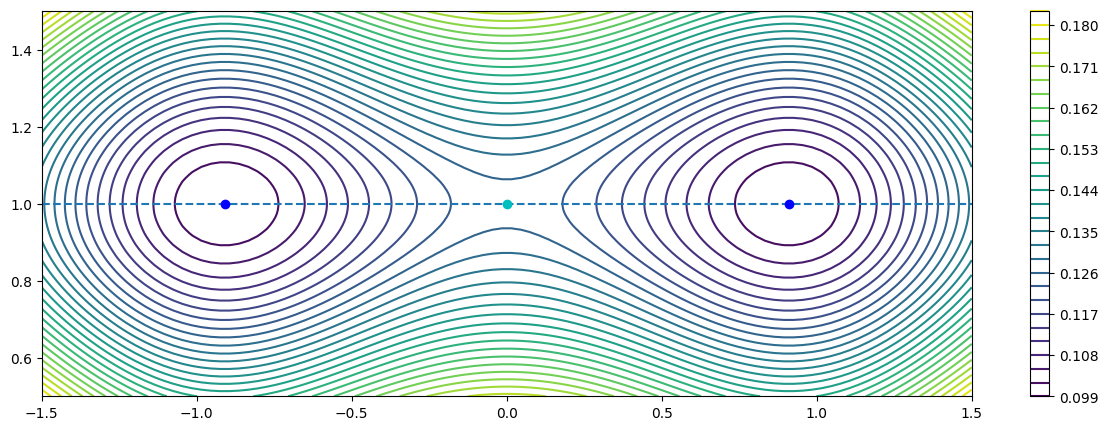

In [ ]:
# Defining the data for the toy problem
Xtoy = np.concatenate((-1*np.eye(2), np.eye(2)))
ytoy = np.ones(4)
ytoy[0] = 1
ytoy[1] = -1

n = Xtoy.shape[0]
d = 2

print(Xtoy,ytoy)

# Plotting the function
delta = 0.5
w1 = np.linspace(-1.5,1.5,100)
w2 = np.linspace(1-delta,1+delta,100)
fw = [[biweightloss(Xtoy,ytoy,np.array([ww1,ww2])) for ww1 in w1] for ww2 in w2]

plt.figure(figsize=(15,5))
plt.contour(w1,w2,fw,levels=30)
plt.plot(w1,np.ones(w1.shape),ls='--')
plt.plot((2*((2)**(1/2)-1))**(1/2),1,'bo')
plt.plot(-(2*((2)**(1/2)-1))**(1/2),1,'ob')
plt.plot(0,1,'co')
plt.colorbar()

### <span style="color:rgb(46,139,87)">Question 1</span>

*a) Justify that the optimal value of the toy problem cannot be $0$.*

*b) Show that the point $\bar{\mathbf{w}}=\left(\begin{array}{cc} 0\\ 1 \end{array}\right)$
is indeed a saddle point of the toy problem.*

#### <span style="color:rgb(46,139,87)">Answer to question 1</span>



... *(write your answer here or in a separate document)*

The next blocks run gradient descent on the toy problem using different starting points.

In [ ]:
# Running gradient descent with fixed stepsize
# Draw a bunch of random points and plot the result

ntrials = 100
w_saddle = np.array([0,1])
val_saddle = biweightloss(Xtoy,ytoy,w_saddle)

# Define initial points and final values according to the boolean
Wf = np.zeros((ntrials+1,d))
vf = np.zeros(ntrials+1)

# Counting the number of "good trials" (those for which GD did not convergescaped the saddle point)
goodtrials = 0

w0 = np.array([0,1.4])
print('Manually chosen starting point:',w0)
Wf[0,:],nits_q,_, obj_q,_,_ = gd_algo(Xtoy,ytoy,w0,maxits=1000,eps=1e-9,linesearch='none')
vf[0] = obj_q[-1]
if vf[0]<val_saddle:
    goodfailpt = 1
else:
    goodfailpt = 0
print(' Value of the last GD iterate for the manually chosen starting point:',Wf[0,:])

print('Random starting points')
# Run multiple instances of GD
for i in range(ntrials):
    w0 = uniform([-1,-1],[1,1],size=d)
    print('Random point '+str(i)+' :',w0)
    Wf[i+1,:],nits_q,_, obj_q,_,_  = gd_algo(Xtoy,ytoy,w0,maxits=1000,eps=1e-9,linesearch='none')
    vf[i+1] = obj_q[-1]
    if vf[i+1]<val_saddle:
        goodtrials += 1
    print(' Final GD iterate:',Wf[i+1,:])

Manually chosen starting point: [0.  1.4]
 Value of the last GD iterate for the manually chosen starting point: [0. 1.]
Random starting points
Random point 0 : [-0.4291835  -0.46172304]
 Final GD iterate: [-0.91017972  1.        ]
Random point 1 : [-0.59652602 -0.64504879]
 Final GD iterate: [-0.91017972  1.        ]
Random point 2 : [ 0.87905039 -0.92584729]
 Final GD iterate: [0.91017972 1.        ]
Random point 3 : [-0.85212037  0.66840897]
 Final GD iterate: [-0.91017972  1.        ]
Random point 4 : [0.21528539 0.60734479]
 Final GD iterate: [0.91017972 1.        ]
Random point 5 : [0.76563825 0.53068126]
 Final GD iterate: [0.91017972 1.        ]
Random point 6 : [-0.78753896 -0.96227608]
 Final GD iterate: [-0.91017972  1.        ]
Random point 7 : [ 0.501128   -0.24907449]
 Final GD iterate: [0.91017972 1.        ]
Random point 8 : [-0.6245165   0.46402565]
 Final GD iterate: [-0.91017972  1.        ]
Random point 9 : [-0.32175643 -0.98045777]
 Final GD iterate: [-0.91017972  1

GD failed on the manually chosen starting point
GD escaped the saddle point  100  times out of  100  random trials


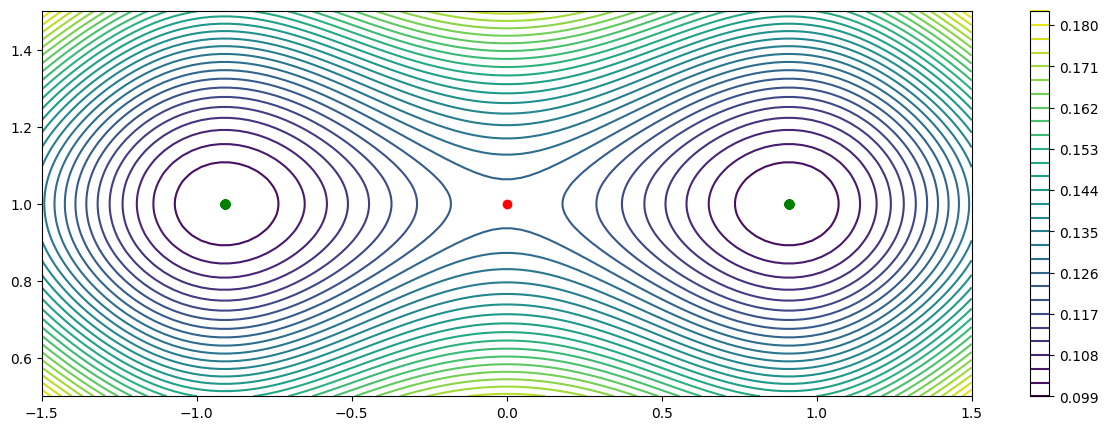

In [ ]:
if goodfailpt:
    print('GD succeeded on the manually chosen starting point')
else:
    print('GD failed on the manually chosen starting point')

print('GD escaped the saddle point ',goodtrials,' times out of ', ntrials,' random trials')

# Plot the results
npts = vf.size
plt.figure(figsize=(15,5))
plt.contour(w1,w2,fw,levels=30)
plt.colorbar()
for i in range(npts):
    if vf[i]<val_saddle:
        plt.plot(Wf[i,0],Wf[i,1],'o',color='green')
    else:
        plt.plot(Wf[i,0],Wf[i,1],'o',color='red')

### <span style="color:rgb(46,139,87)">Question 2</span>

*a) Why does the first run of gradient descent starting from $\mathbf{w}_0 = \begin{bmatrix} 0 \\ 1.4 \end{bmatrix}$ converge to the saddle point?*

*b) A research paper from 2015 showed that gradient descent escapes saddle points for almost initial initial point. How does this experiment confirm the results of the theorem?*

#### <span style="color:rgb(46,139,87)">Answer to question 2</span>

... *(write your answer here or in a separate document)*

## <span style="color:rgb(46,139,87)">1.5 A dataset poised for robust regression</span>

In this section, we return to the generic formulation of the problem. We consider a dataset of the form $\{(\mathbf{x}_i,y_i)\}_{i=1}^n$, where $\mathbf{x}_i \in \mathbb{R}^d$, $y_i \in \mathbb{R}$ for every $i$. We will use $d=30$ and $n=60$.

Every vector $\mathbf{x}_i$ is generated according to a Gaussian distribution of zero mean and identity covariance matrix, which we denote as $\mathbf{x}_i \sim \mathcal{N}(\mathbf{0},\mathbf{I}_d)$, where $\mathbf{I}_d$ is the identity matrix in $\mathbb{R}^{d \times d}$.

We generate the vector $\mathbf{y}=[y_i]_{i=1}^n$ according to the following formula:
$$
    \mathbf{y} = \mathbf{X} \mathbf{\xi}_1 + 3 \mathbf{\xi}_2 + \mathbf{\xi}_3,
$$
where
- $\mathbf{\xi}_1 \sim \mathcal{N}(0,4 I_d)$,
- $\mathbf{\xi}_2 \sim \mathcal{N}(0,I_n)$,
- $\mathbf{\xi}_3 \in \mathbb{R}^n$ has i.i.d. components drawn following a Bernoulli distribution of parameter 0.3.

This procedure produces a dataset that is well suited for robust regression formulations.

In [ ]:
# Data generation function
def datagen(d,n):
    '''
    Generate a dataset amenable to nonconvex linear regression.

    Inputs:
        d: Dimension of the parameter space
        n: Number of data points

    Outputs:
        X: n x d matrix
        y: Real vector with n components
    '''

    X = multivariate_normal(np.zeros(d),np.identity(d),size=n)

    xi1 = multivariate_normal(np.zeros(d),4*np.identity(d))

    xi2 = multivariate_normal(np.zeros(n),np.identity(n))

    xi3 = binomial(1,0.3,n)

    y = X.dot(xi1) + 3*xi2 + xi3

    return X,y

In [ ]:
# Generation of the dataset
d = 30
n = 60

np.random.seed(1)

Xr,yr = datagen(d,n)
w0 = np.ones(d)

**Assignment: Fill out the code below to run gradient descent with both a constant and an adaptive stepsize on the desired problem.**

In [ ]:
# Running gradient descent with both constant and adaptive stepsizes

#################################
# FILL OUT THIS SECTION
# - Call gradient descent with a constant stepsize rule, a budget of 1000 iterations and
# a tolerance of 1e-5
w_c, nits_c, nfevals_c, objvals_c, ngrads_c,flag_c = gd_algo(
    Xr, yr, w0,
    maxits=1000,
    eps=1e-5,
    linesearch='none'
)
# - Call gradient descent with an adaptive stepsize rule (Armijo line search), a budget of
# 1000 iterations and a tolerance of 1e-5
w_a, nits_a, nfevals_a, objvals_a, ngrads_a,flag_a = gd_algo(
    Xr, yr, w0,
    maxits=1000,
    eps=1e-5,
    linesearch='armijo'
)

print('Constant stepsize')
print(' Number of iterations:',nits_c)
print(' Number of function calls:',nfevals_c)
print(' Last function value:',objvals_c[-1])
print(' Last gradient norm:',ngrads_c[-1])
print('Adaptive stepsize')
print(' Number of iterations:',nits_a)
print(' Number of function calls:',nfevals_a)
print(' Last function value:',objvals_a[-1])
print(' Last gradient norm:',ngrads_a[-1])

Constant stepsize
 Number of iterations: 1000
 Number of function calls: 1001
 Last function value: 0.410180251042066
 Last gradient norm: 0.04034721885878601
Adaptive stepsize
 Number of iterations: 1000
 Number of function calls: 1999
 Last function value: 0.31094468092593686
 Last gradient norm: 0.002381488100290579


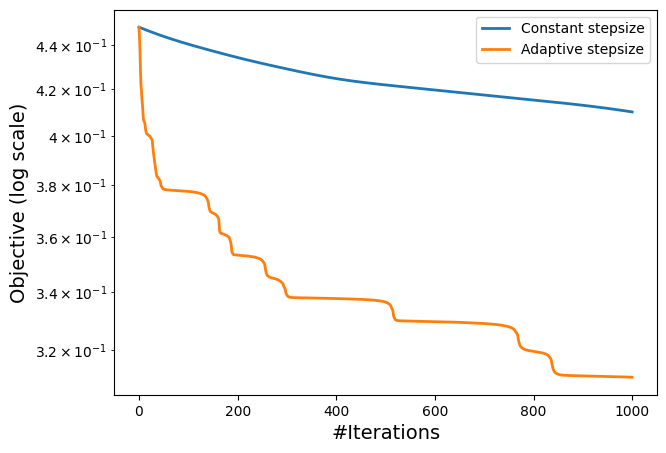

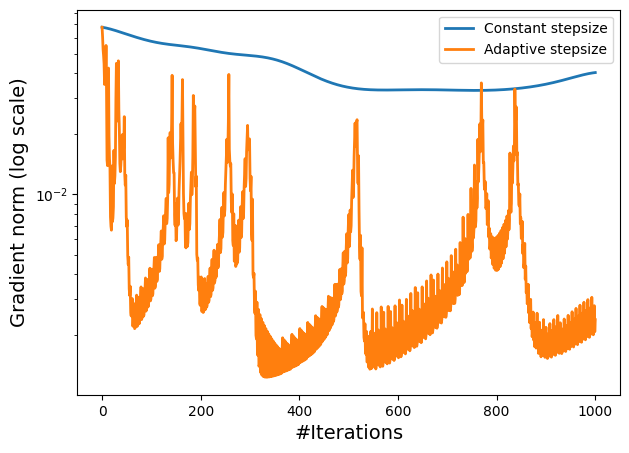

In [ ]:
# Plot convergence curves of both methods
plt.figure(figsize=(7, 5))
plt.semilogy(objvals_c, label='Constant stepsize',lw=2)
plt.semilogy(objvals_a, label='Adaptive stepsize',lw=2)
plt.xlabel('#Iterations',fontsize=14)
plt.ylabel('Objective (log scale)',fontsize=14)
plt.legend()

plt.figure(figsize=(7, 5))
plt.semilogy(ngrads_c, label='Constant stepsize',lw=2)
plt.semilogy(ngrads_a, label='Adaptive stepsize',lw=2)
plt.xlabel('#Iterations',fontsize=14)
plt.ylabel('Gradient norm (log scale)',fontsize=14)
plt.legend()

### <span style="color:rgb(46,139,87)">Question 3</span>

*a) What stepsize strategy seems the most efficient? Justify your answer by taking into account the cost of both strategies.*

*b) Do the gradient norms curves correspond to the theoretical convergence rate of gradient descent (in $\mathcal{O}(1/\sqrt{K})$ for nonconvex functions, where $K$ is the iteration index)? Is that surprising?*

#### <span style="color:rgb(46,139,87)">Answer to question 3</span>

... *(write your answer here or in a separate document)*

## <span style="color:rgb(46,139,87)">Part 2 - Stochastic gradient and robust regression</span>

In this part of the project, we build upon the nonconvex formulation from Part 1, but rely on stochastic rather than deterministic techniques.

## <span style="color:rgb(46,139,87)">2.1 Formulation</span>

Given a data set under the form of a matrix $\mathbf{X} = [\mathbf{x}_i]_{i=1}^n \in \mathbb{R}^{n \times d}$ and a vector $\mathbf{y} = [y_i]_{i=1}^n \in \mathbb{R}^n$, we seek a solution to the following regression problem
$$
    \mbox{minimize}_{\mathbf{w} \in \mathbb{R}^d} f(\mathbf{w})= \frac{1}{n}\sum_{i=1}^n
    f_i(\mathbf{w}), \quad f_i(\mathbf{w}):= \frac{1}{2} \phi(\mathbf{x}_i^T \mathbf{w} - y_i),
$$
where $\phi: [0,\infty) \rightarrow [0,\infty)$ is the biweight loss function given by $\phi(t) = \frac{t^2}{1+t^2}$.

The function $f$ is twice continuously differentiable; moreover, for every $\mathbf{w} \in \mathbb{R}^d$, we have
$$
    \nabla f(\mathbf{w}) = \frac{1}{n} \sum_{i=1}^n \nabla f_i(\mathbf{w}),
    \quad \nabla f_i(\mathbf{w})= \frac{\mathbf{x}_i^T \mathbf{w} -y_i}
    {(1+(\mathbf{x}_i^T \mathbf{w} - y_i)^2)^2}\,\mathbf{x}_i.
$$
As explained above, this gradient function is $L$-Lipschitz continuous with
$L= \frac{1}{n}\left\|\mathbf{X}^T\right\|\|\mathbf{X}\|$.

The code below implements $\nabla f_i(\mathbf{w})$.

In [ ]:
### Gradient of one sample for the biweight problem objective function
def biweightgrad_i(X,y,i,w):
    '''
        Gradient of a Tukey biweight loss function for a
        linear regression problem.

        Given a dataset (X,y) of n elements, this function
        computes for any w in R^d the value
            g_i(w)=(x_i^T w-y_i)/(1+(x_i^T w - y)^2))^2 * x_i

        Inputs:
            X: n by d matrix
            y: n-dimensonal data vector
            i: index for the data point
            w: argument of the loss function (d-dimensional)

        Output:
            Gradient of the empirical loss value at w
    '''
    x_i = X[i]
    ri = x_i.dot(w) - y[i]
    si = ri/((1+ri**2)**2)
    gi = si*x_i
    return gi


## <span style="color:rgb(46,139,87)">2.2 Stochastic gradient algorithm</span>

This section provides an implementation of stochastic gradient inspired by the corresponding lab session. This method includes the option of using a batch variant.

In [ ]:
# Implementation of stochastic gradient techniques
def stoch_grad(X,y,w0,stepchoice=0,step0=1, n_iter=1000,nb=1,with_replace=False,verbose=False):
    """
        Stochastic gradient framework.

        Inputs:
            X: n by d matrix of feature vectors
            y: vector of dimension n (labels)
            w0: Initial vector
            stepchoice: Stepsize/Learning rate strategy
                0: Constant stepsize equal to 1/L
                t>0: Stepsize proportional to 1/(k+1)**t
            step0: Initial stepsize (used when stepchoice>0)
            n_iter: Number of iterations
            nb: Batch size (Default: 1)
            with_replace: Drawing indices with/without replacement
                True: With replacement
                False: Without replacement (Default)
            verbose: Boolean indication whether epoch-related info are to be displayedées à chaque epoch (default : False)

        Outputs :
            w_output: Final iterate
            objvals: History of function values (NumPy array of length n_iter)
            distits: History of distance to optimal point (NumPy array of length n_iter)
    """
    ############
    # Initialization

    # History of function values and distance to a theoretical optimum
    objvals = []
    normits = []

    # Lipschitz constant
    L = np.amax(np.diag(X.dot(X.T)))

    # Problem dimensions
    n,d = X.shape

    # Initial value for the iterate
    w = w0.copy()
    nw = norm(w)

    # Iteration
    k=0

    # Initial quantities of interest
    obj = biweightloss(X,y,w)
    objvals.append(obj);

    if verbose:
        # Plotting info if required
        print("Stochastic Gradient, batch size=",nb,"/",n)
        print(' | '.join([name.center(8) for name in ["iter", "fval"]]))
        print(' | '.join([("%d" % k).rjust(8),("%.2e" % obj).rjust(8)]))

    ################
    # Main loop
    while (k < n_iter and nw < 10**100):

        # Draw random index or indices
        ik = np.random.choice(n,nb,replace=with_replace)
        # Compute the stochastic gradient approximation
        sg = np.zeros(d)
        for j in range(nb):
            gi = biweightgrad_i(X,y,ik[j],w)
            sg = sg + gi
        sg = (1/nb)*sg


        #######

        if stepchoice==0:
            w[:] = w - (step0/L) * sg
        elif stepchoice>0:
            sk = float(step0/((k+1)**stepchoice))
            w[:] = w - sk * sg

        nw = norm(w) #Compute the norm of the iterate (prevents divergence)

        obj = biweightloss(X,y,w)

        k += 1
        # Compute quantities of interest at the end of every epoch
        if (k*nb) % n == 0:
            objvals.append(obj)
            if verbose:
                print(' | '.join([("%d" % k).rjust(8),("%.2e" % obj).rjust(8)]))

    # End main loop
    #################

    # Final information
    if (k*nb) % n > 0:
        objvals.append(obj)
        if verbose:
            print(' | '.join([("%d" % k).rjust(8),("%.2e" % obj).rjust(8)]))

    # Outputs
    w_output = w.copy()

    return w_output, np.array(objvals)

#### <span style="color:rgb(46,139,87)">Question 4</span>

*Consider one more time the toy problem of Part 1.*

*a) Consider a run of batch stochastic gradient such that $\calS_k = \{2,4\}$. Show that the resulting stochastic gradient is identical to that of a stochastic gradient iteration with $i_k=4$.*

*b) For this nonconvex problem, it can be shown that a stochastic gradient method has a convergence rate in $\mathcal{O}(\tfrac{1}{K^{1/4}})$ where $K$ is the iteration count. Is it better or worse than the rate of gradient descent? Is there a setting in which we can consider stochastic gradient to be more efficient?*

*c) Do you expect stochastic gradient to outperform gradient descent on the toy example?*

#### <span style="color:rgb(46,139,87)">Answer to question 4</span>

... *(write your answer here or in a separate document)*

## <span style="color:rgb(46,139,87)">2.3 Comparison of stochastic gradient methods on the synthetic dataset</span>

We now rely on the same synthetic data construction than in Part 1, yet using more samples.

**Assignment: Fill out the code below to run several variants of (batch) stochastic gradient, including gradient descent for 100 epochs. All variants should use a stepsize of 1/L and should be run for the appropriate number of iterations corresponding to 100 epochs.**

In [ ]:
# Generation of the dataset
d = 30
n = 600

np.random.seed(1)

Xr,yr = datagen(d,n)
w0 = multivariate_normal(np.ones(d),np.identity(d))


nb_epochs = 100

#####################################################################################
# FILL OUT THIS SECTION

# Stochastic gradient (batch size=1)
w_a, obj_a = stoch_grad(Xr,yr,w0,stepchoice=0,step0=1, n_iter=nb_epochs*n,nb=1)

# Batch SG avec batch_size = n/200
nb_b = n // 200
w_b, obj_b = stoch_grad(
    Xr, yr, w0,
    stepchoice=0,
    step0=1,
    n_iter=nb_epochs * (n // nb_b),
    nb=nb_b
)

# Batch SG avec batch_size = n/60
nb_c = n // 60
w_c, obj_c = stoch_grad(
    Xr, yr, w0,
    stepchoice=0,
    step0=1,
    n_iter=nb_epochs * (n // nb_c),
    nb=nb_c
)

# Batch SG avec batch_size = n/20
nb_d = n // 20
w_d, obj_d = stoch_grad(
    Xr, yr, w0,
    stepchoice=0,
    step0=1,
    n_iter=nb_epochs * (n // nb_d),
    nb=nb_d
)

# - Call gradient descent (batch size=n, indices drawn without replacement)
w_f, obj_f = stoch_grad(
    Xr, yr, w0,
    stepchoice=0,
    step0=1,
    n_iter=nb_epochs,
    nb=n,
    with_replace=False
)

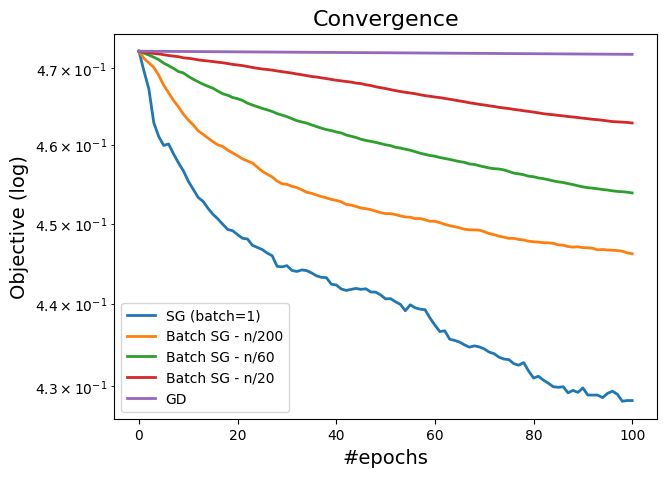

In [ ]:
# Results of the comparison

# In terms of objective function (log)
plt.figure(figsize=(7, 5))
plt.semilogy(obj_a, label="SG (batch=1)", lw=2)
plt.semilogy(obj_b, label="Batch SG - n/200", lw=2)
plt.semilogy(obj_c, label="Batch SG - n/60", lw=2)
plt.semilogy(obj_d, label="Batch SG - n/20", lw=2)
plt.semilogy(obj_f, label="GD", lw=2)
plt.title("Convergence", fontsize=16)
plt.xlabel("#epochs", fontsize=14)
plt.ylabel("Objective (log)", fontsize=14)
plt.legend()

### <span style="color:rgb(46,139,87)">Question 5</span>

*a) According to the plots, is stochastic gradient performing better than gradient descent?*

*b) What value of the batch size (among those tested) appears to be the most efficient? How would you suggest a better value?*

#### <span style="color:rgb(46,139,87)">Answer to question 5</span>

... *(write your answer here or in a separate document)*

# <span style="color:rgb(46,139,87)">Part 3 - Robust nonconvex regression and regularization</span>

The goal of this part of the project is to add a (smooth) regularization term to the nonconvex regression problem at hand, and to tackle the resulting problem using both gradient descent and proximal gradient.

## <span style="color:rgb(46,139,87)">3.1 Optimization formulation</span>

Given a data set under the form of a matrix $\mathbf{X} = [\mathbf{x}_i]_{i=1}^n \in \mathbb{R}^{n \times d}$ and a vector $\mathbf{y} = [y_i]_{i=1}^n \in \mathbb{R}^n$, we seek a solution to the following regression problem
$$
    \mbox{minimize}_{\mathbf{w} \in \mathbb{R}^d} f_2(\mathbf{w}):= f(\mathbf{w} + \frac{\lambda}{2}\|\mathbf{w}\|^2,
$$
where $f(\mathbf{w}):= \frac{1}{2 n} \sum_{i=1}^n\phi(\mathbf{x}_i^T \mathbf{w} - y_i)$, $\phi: [0,\infty) \rightarrow [0,\infty)$ is the biweight loss function given by $\phi(t) = \frac{t^2}{1+t^2}$ and $\lambda>0$.

The function $f$ is twice continuously differentiable thus the function $f_2$ also is. Moreover, for every $\mathbf{w} \in \mathbb{R}^d$, we have
$$
    \nabla f_2(\mathbf{w}) = \nabla f(\mathbf{w}) + \lambda \mathbf{w},
$$
where
$$
    \nabla f(\mathbf{w}) = \frac{1}{n} \sum_{i=1}^n \frac{\mathbf{x}_i^T \mathbf{w} -y_i}
    {(1+(\mathbf{x}_i^T \mathbf{w} - y_i)^2)^2}\,\mathbf{x}_i = \frac{1}{n} \mathbf{X}^T \mathbf{z} \in \mathbb{R}^d,
    \qquad
    \mathbf{z}= \left[ \frac{\mathbf{x}_i^T \mathbf{w} -y_i}
    {(1+(\mathbf{x}_i^T \mathbf{w} - y_i)^2)^2} \right] \in \mathbb{R}^n.
$$


*Note: For every $x \in \mathbb{R}^d$, we have $\|\nabla^2 f_2(\mathbf{x})\| \le \frac{1}{n}\left\|\mathbf{X}^T\right\|\|\mathbf{X}\|+\lambda$, therefore the function $f_2$ has a Lipschitz continuous gradient.*

## <span style="color:rgb(46,139,87)">3.2 Gradient descent and proximal gradient</span>

This section provides an implementation of both gradient descent and proximal gradient for the problem at hand. For simplicity, we focus on using a constant stepsize.

**Assignment: Fill out the missing part in the code.**

In [ ]:
## Generic method for both gradient descent and proximal gradient
def reg_algo(X,y,lbda,w0,maxits=1000,eps=1e-4,algo='gd',info=False):
    '''
        Gradient descent method for the robust regression problem.

        Inputs:
            X: n by d matrix of feature vectors
            y: vector of dimension n (labels)
            lbda: regularization parametr
            w0: initial point, d-dimensional vector
            maxits: Maximum number of iterations of the method
            eps: Tolerance for the gradient norm
            algo: Algo type
                'gd': Gradient descent
                'pg': Proximal gradient
            info: Boolean parameter, whether to display information about the iterations or not

        Outputs:
            w_output: Last iterate computed (NumPy array of length d)
            nits: Number of iterations
            nfevals: Number of function evaluations that were used
            objvals: History of function values (NumPy array of length nits)
            ngrads: History of gradient norms (NumPy array of length nits)
            flag: Convergence flag
                0: The algorithm converged
                1: The maximum number of iterations was reached
                -1: An error occurred

    '''

    ############
    # Initialization: Compute and plot some initial quantities

    # Problem dimensions
    n,d = X.shape

    # Initial value of current iterate
    w = w0.copy()


    # History of objective function values
    objvals = []

    # History of gradient norms
    ngrads = []

    # Initialize iteration counter
    nits=0

    # Initialize number of function evaluations
    nfevals = 0

    # Set convergence flag
    flag = -1

    L = np.amax(np.diag(X.dot(X.T))) + lbda
    alpha = 1/L

    # Current objective
    obj = biweightloss(X,y,w)+ 0.5*lbda*(norm(w)**2)
    objvals.append(obj)
    nfevals += 1

    # Current gradient norm
    grad = biweightgrad(X,y,w)+lbda*w
    ng = norm(grad)
    ngrads.append(ng)

    # Plot the initial values
    if info:
        print("\nGradient Descent, Problem=",pb,", Algo=",algo)
        print("Fixed step size:",1/L)
        print(' | '.join([name.center(8) for name in ["iter", "obj", "grad"]]))
        print(' | '.join([("%d" % nits).rjust(8),("%.2e" % obj).rjust(8),("%.2e" % ng).rjust(8)]))

    if (ng<eps):
        flag = 0

    ####################
    # Main loop
    while (flag==-1):

        ######################
        # PART TO BE FILLED OUT
        if algo == 'gd':
            # Gradient descent iterate
            w[:] = w - (1/L) * grad

        elif algo == 'pg':
            # Proximal gradient iterate
            alpha = 1/L
            g_f = biweightgrad(X, y, w)
            w_temp = w - alpha * g_f
            w[:] = (1 / (1 + alpha * lbda)) * w_temp


        # END PART TO BE FILLED OUT
        ######################

        # Compute and plot the new objective value and gradient norm
        obj = biweightloss(X,y,w) + 0.5*lbda*(norm(w)**2)
        nfevals += 1

        objvals.append(obj)

        grad = biweightgrad(X,y,w)+lbda*w
        ng = norm(grad)
        ngrads.append(ng)

        # Increment the iteration count
        nits += 1

        # Print relevant information
        if info:
            print(' | '.join([("%d" % nits).rjust(8),("%.2e" % obj).rjust(8),("%.2e" % ng).rjust(8),("%.2e" % alpha).rjust(8)]))

        # Adjusting the convergence criterion
        if (ng<eps):
            flag=0
        elif (nits>=maxits):
            flag=1

    # End main loop
    ######################

    # Output
    w_output = w.copy()

    return w_output, nits, nfevals, np.array(objvals), np.array(ngrads),flag

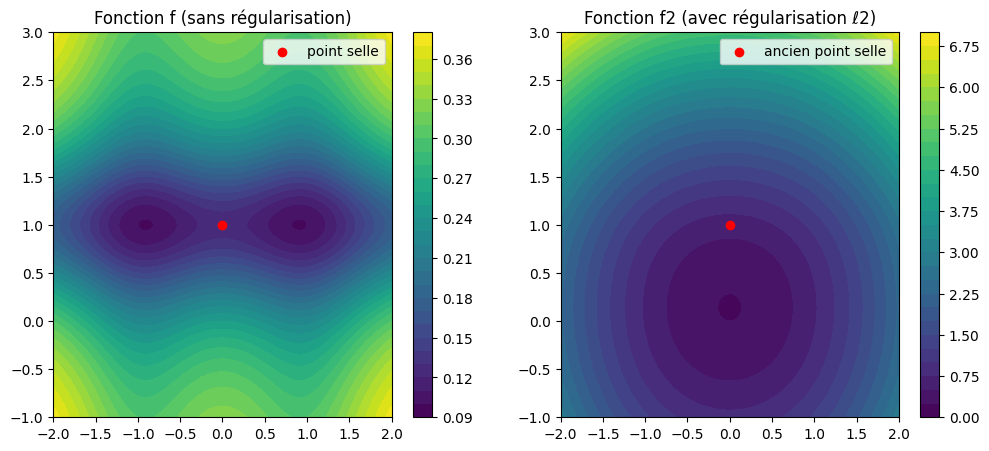

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Données du toy problem
X = np.array([
    [-1, 0],
    [0, -1],
    [1, 0],
    [0, 1]
])
y = np.array([1, -1, 1, 1])
n = len(y)

# Fonction biweight
def phi(t):
    return t**2 / (1 + t**2)

# Fonction objectif f
def f(w):
    r = X @ w - y
    return 0.5/n * np.sum(phi(r))

# Fonction régularisée f2
def f2(w, lbda=1):
    return f(w) + 0.5*lbda*np.linalg.norm(w)**2

# Grille
w1 = np.linspace(-2, 2, 200)
w2 = np.linspace(-1, 3, 200)
W1, W2 = np.meshgrid(w1, w2)

Zf = np.zeros_like(W1)
Zf2 = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w = np.array([W1[i,j], W2[i,j]])
        Zf[i,j] = f(w)
        Zf2[i,j] = f2(w, lbda=1)

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.contourf(W1, W2, Zf, levels=30)
plt.colorbar()
plt.title("Fonction f (sans régularisation)")
plt.scatter([0], [1], color='red', label='point selle')
plt.legend()

plt.subplot(1,2,2)
plt.contourf(W1, W2, Zf2, levels=30)
plt.colorbar()
plt.title("Fonction f2 (avec régularisation ℓ2)")
plt.scatter([0], [1], color='red', label='ancien point selle')
plt.legend()

plt.show()


### <span style="color:rgb(46,139,87)">Question 6</span>

*Consider (for the last time) the toy problem, but now with regularization.*

*a) Justify that the saddle point of question 1 is no longer a saddle point of the problem with $\lambda>0$.*

*b) Write down the iterations of gradient descent and proximal gradient descent applied to the toy problem with $\mathbf{w}_0=\bar{\mathbf{w}}$, and compare the value of $\mathbf{w}_1$.*

#### <span style="color:rgb(46,139,87)">Answer to question 6</span>

...

## <span style="color:rgb(46,139,87)">3.3 Experiments</span>

In this section, we return to the generic formulation of the proble, and consider one more time our synthetic data setup.

In [ ]:
# Generation of the dataset
d = 60
n = 30

np.random.seed(1)

Xr,yr = datagen(d,n)
lbda = 1/(n**0.5)
w0 = np.ones(d)

**Assignment: Fill out the code below to run gradient descent and proximal gradient on the desired problem.**

In [ ]:
# Compare gradient descent and proximal gradient

################################################################
# FILL OUT THIS SECTION

# - Call gradient descent with a budget of 1000 iterations and a tolerance of 1e-5
w_g, nits_g, nfevals_g, objvals_g, ngrads_g,flag_g = reg_algo(
    Xr, yr, lbda, w0,
    maxits=1000,
    eps=1e-5,
    algo='gd'
)
# - Call proximal gradient with a budget of 1000 iterations and a tolerance of 1e-5
w_p, nits_p, nfevals_p, objvals_p, ngrads_p,flag_p = reg_algo(
    Xr, yr, lbda, w0,
    maxits=1000,
    eps=1e-5,
    algo='pg'
)
################################################################

print('Gradient descent')
print(' Number of iterations:',nits_g)
print(' Number of function calls:',nfevals_g)
print(' Last function value:',objvals_g[-1])
print(' Last function value (unregularized):',objvals_g[-1]-0.5*lbda*(norm(w_g)**2))
print('Proximal gradient')
print(' Number of iterations:',nits_p)
print(' Number of function calls:',nfevals_p)
print(' Last function value:',objvals_p[-1])
print(' Last function value (unregularized):',objvals_p[-1]-0.5*lbda*(norm(w_p)**2))

Gradient descent
 Number of iterations: 1000
 Number of function calls: 1001
 Last function value: 0.5657679855504388
 Last function value (unregularized): 0.4642707173086429
Proximal gradient
 Number of iterations: 1000
 Number of function calls: 1001
 Last function value: 0.5666476059648943
 Last function value (unregularized): 0.4643613134626472


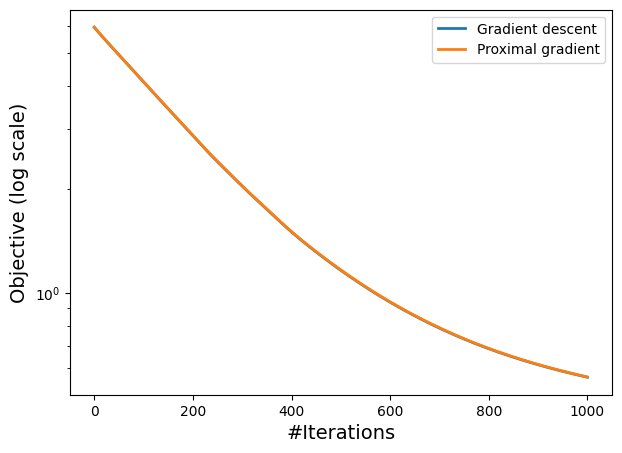

In [ ]:
# Plot convergence curves of both methods
plt.figure(figsize=(7, 5))
plt.semilogy(objvals_g, label='Gradient descent',lw=2)
plt.semilogy(objvals_p, label='Proximal gradient',lw=2)
plt.xlabel('#Iterations',fontsize=14)
plt.ylabel('Objective (log scale)',fontsize=14)
plt.legend()

### <span style="color:rgb(46,139,87)">Question 7</span>

*a) According to the plot, which method performs best? How do you interpret this?*

*b) Change the value of $\lambda$ to a much larger value. What do you observe? Is it consistent with the properties of $\ell_2$ regularization?*

#### <span style="color:rgb(46,139,87)">Answer to question 7</span>

... *(write your answer here or in a separate document)*

In [ ]:
# Version 1.0 - C. W. Royer, January 2026.